# 11 · Interpretability

[← Course home](../README.md)

A model that scores well is not automatically a model you understand — or one you should trust.
This chapter is about asking a fitted model *why*: which features matter, in which direction, and how.

**What you will learn**

- The two axes of interpretability: **global vs local** and **intrinsic vs post-hoc**
- Reading **linear coefficients** correctly (standardised features) and their pitfalls (scale, correlated features)
- Why **impurity-based (MDI) feature importance** in random forests is biased toward high-cardinality features —
  demonstrated with random noise columns on Titanic
- **Permutation importance** on held-out data, implemented **from scratch** and verified against
  `sklearn.inspection.permutation_importance`
- How **correlated features** fool permutation importance, and the Spearman-clustering remedy
- **Partial dependence (PDP)** and **ICE** curves, 2-D interaction PDPs, and a from-scratch PDP verified against sklearn
- Where SHAP and LIME fit in (further reading)

In [1]:
import time

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_diabetes
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, partial_dependence, permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from mlaz import PALETTE, load_mpg, load_titanic, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
T0 = time.time()

## 1 · A map of interpretability methods

| | **Global** (whole model) | **Local** (one prediction) |
|---|---|---|
| **Intrinsic** (read off the model) | linear coefficients, a small tree's structure | $\beta_j (x_j - \bar x_j)$ contributions, a tree's decision path |
| **Post-hoc** (probe any black box) | permutation importance, partial dependence | ICE curves, SHAP values, LIME |

*Intrinsic* methods are exact but only exist for simple model classes. *Post-hoc* methods are model-agnostic —
they treat the model as a function $\hat f(x)$ and poke it — but they come with their own assumptions and pitfalls.

> **Important:** every method here explains the **model**, not the world. A feature can be important *to the model*
> without being a *cause* of the outcome.

## 2 · Linear models: coefficients and their pitfalls

For $\hat y = \beta_0 + \sum_j \beta_j x_j$, the coefficient $\beta_j$ is the change in prediction when $x_j$ increases
by **one unit** and every other feature is **held fixed**. Both halves of that sentence hide a pitfall.

We predict fuel economy (`mpg`) of 392 cars from engine and body characteristics.

In [2]:
mpg = load_mpg().dropna(subset=["horsepower"])
num_mpg = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
mpg[num_mpg] = mpg[num_mpg].astype(float)   # PDP tools refuse integer columns (grid values would be rounded)
X_mpg, y_mpg = mpg[num_mpg], mpg["mpg"]
X_mtr, X_mte, y_mtr, y_mte = train_test_split(X_mpg, y_mpg, test_size=0.25, random_state=RANDOM_STATE)
print(X_mtr.shape, X_mte.shape)
X_mtr.describe().loc[["mean", "std"]].round(1)

(294, 6) (98, 6)


,cylinders,displacement,horsepower,weight,acceleration,model_year
mean,5.5,195.5,104.5,2971.8,15.5,76.1
std,1.7,104.7,38.6,841.8,2.9,3.7


### Pitfall 1 — scale

Raw coefficients are in "mpg per unit of $x_j$". `weight` is in pounds (std ≈ 850) while `cylinders` has std ≈ 1.7,
so the raw coefficients are not comparable. Standardising ($z_j = (x_j-\bar x_j)/s_j$) turns every coefficient into
"mpg per **one standard deviation**", which *is* comparable:

$$\beta_j^{\text{std}} = \beta_j^{\text{raw}} \cdot s_j .$$

In [3]:
ols_raw = LinearRegression().fit(X_mtr, y_mtr)
ols_std = make_pipeline(StandardScaler(), LinearRegression()).fit(X_mtr, y_mtr)
coefs = pd.DataFrame({
    "raw coef (mpg / unit)": ols_raw.coef_,
    "std coef (mpg / SD)": ols_std[-1].coef_,
    "raw × SD": ols_raw.coef_ * X_mtr.std(ddof=0).to_numpy(),
}, index=num_mpg)
print("test R²:", round(ols_std.score(X_mte, y_mte), 3))
coefs.round(4)

test R²: 0.799


,raw coef (mpg / unit),std coef (mpg / SD),raw × SD
cylinders,-0.1601,-0.2738,-0.2738
displacement,0.0004,0.0390,0.0390
horsepower,-0.0019,-0.0732,-0.0732
weight,-0.0065,-5.4259,-5.4259
acceleration,0.0576,0.1642,0.1642
model_year,0.7623,2.7786,2.7786


The last column confirms $\beta^{\text{std}} = \beta^{\text{raw}} s_j$ (StandardScaler uses the population SD).
The raw weight coefficient looks tiny (−0.007) only because one pound is a tiny unit; per SD it is the dominant effect.

### Pitfall 2 — correlated features

`cylinders`, `displacement`, `horsepower` and `weight` are all "engine size" and strongly correlated. "Holding the
others fixed" is then an unrealistic thought experiment, and OLS can trade one coefficient against another
with little change in fit — coefficients become **unstable** and may even take counter-intuitive signs.
We make the instability visible with a bootstrap: refit on 200 resamples of the training set.

In [4]:
print(X_mtr.corr().round(2).loc[["cylinders", "displacement", "horsepower", "weight"],
                                 ["cylinders", "displacement", "horsepower", "weight"]])

B = 200
boot = {"OLS": [], "Ridge (CV α)": []}
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))).fit(X_mtr, y_mtr)
alpha = ridge[-1].alpha_
for b in range(B):
    idx = rng.integers(0, len(X_mtr), len(X_mtr))
    Xb, yb = X_mtr.iloc[idx], y_mtr.iloc[idx]
    boot["OLS"].append(make_pipeline(StandardScaler(), LinearRegression()).fit(Xb, yb)[-1].coef_)
    boot["Ridge (CV α)"].append(make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(Xb, yb)[-1].coef_)
boot = {k: np.array(v) for k, v in boot.items()}
summary = pd.DataFrame({
    "OLS mean": boot["OLS"].mean(axis=0), "OLS 95% CI": [f"[{lo:+.2f}, {hi:+.2f}]" for lo, hi in np.percentile(boot["OLS"], [2.5, 97.5], axis=0).T],
    "OLS sign flips %": (np.sign(boot["OLS"]) != np.sign(boot["OLS"].mean(axis=0))).mean(axis=0) * 100,
    "Ridge 95% CI": [f"[{lo:+.2f}, {hi:+.2f}]" for lo, hi in np.percentile(boot["Ridge (CV α)"], [2.5, 97.5], axis=0).T],
}, index=num_mpg)
print(f"Ridge alpha chosen by CV: {alpha:.2f}")
summary.round(2)

              cylinders  displacement  horsepower  weight
cylinders          1.00          0.96        0.85    0.89
displacement       0.96          1.00        0.89    0.93
horsepower         0.85          0.89        1.00    0.86
weight             0.89          0.93        0.86    1.00


Ridge alpha chosen by CV: 2.59


,OLS mean,OLS 95% CI,OLS sign flips %,Ridge 95% CI
cylinders,-0.32,"[-1.79, +1.38]",35.0,"[-1.54, +0.95]"
displacement,0.09,"[-2.06, +2.24]",45.5,"[-1.89, +1.45]"
horsepower,-0.06,"[-1.30, +1.00]",51.0,"[-1.48, +0.65]"
weight,-5.41,"[-6.84, -4.05]",0.0,"[-6.18, -3.83]"
acceleration,0.19,"[-0.54, +1.01]",34.5,"[-0.62, +0.78]"
model_year,2.77,"[+2.29, +3.24]",0.0,"[+2.25, +3.18]"


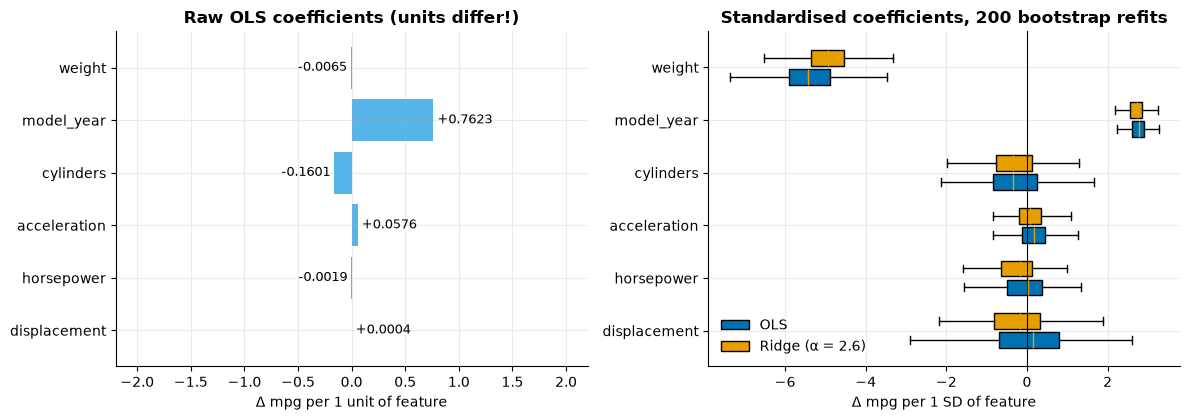

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
order = np.argsort(np.abs(coefs["std coef (mpg / SD)"].to_numpy()))
axes[0].barh(np.array(num_mpg)[order], coefs["raw coef (mpg / unit)"].to_numpy()[order], color=PALETTE[5], label="raw (per unit)")
for i, j in enumerate(order):
    v = coefs["raw coef (mpg / unit)"].iloc[j]
    axes[0].text(v, i, f" {v:+.4f} ", va="center", ha="left" if v >= 0 else "right", fontsize=9)
axes[0].set(title="Raw OLS coefficients (units differ!)", xlabel="Δ mpg per 1 unit of feature")
axes[0].set_xlim(-2.2, 2.2)
bp = axes[1].boxplot([boot["OLS"][:, j] for j in order], positions=np.arange(len(order)) - 0.18, widths=0.3,
                     orientation="horizontal", patch_artist=True, showfliers=False)
bp2 = axes[1].boxplot([boot["Ridge (CV α)"][:, j] for j in order], positions=np.arange(len(order)) + 0.18, widths=0.3,
                      orientation="horizontal", patch_artist=True, showfliers=False)
for patch in bp["boxes"]: patch.set_facecolor(PALETTE[0])
for patch in bp2["boxes"]: patch.set_facecolor(PALETTE[1])
axes[1].set_yticks(np.arange(len(order)), np.array(num_mpg)[order])
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set(title=f"Standardised coefficients, {B} bootstrap refits", xlabel="Δ mpg per 1 SD of feature")
axes[1].legend([bp["boxes"][0], bp2["boxes"][0]], ["OLS", f"Ridge (α = {alpha:.1f})"], loc="lower left")
fig.tight_layout()
savefig("linear_coefficients")
plt.show()

The standardised view makes `weight` and `model_year` the big effects. But the correlated engine-size group
(`cylinders`, `displacement`, `horsepower`) has wide bootstrap intervals straddling zero: the data cannot
decide how to share the "engine size" effect among them. Ridge shrinks and stabilises them — at the cost of a little
bias. **Interpret the group, not the individual coefficient.**

### A local, intrinsic explanation

For a linear model a single prediction decomposes *exactly* into per-feature contributions relative to the average car:

$$\hat y(x) = \underbrace{\beta_0 + \sum_j \beta_j \bar x_j}_{\text{average prediction}} + \sum_j \underbrace{\beta_j (x_j - \bar x_j)}_{\text{contribution of } j}.$$

(This is exactly what SHAP values reduce to for a linear model with independent features.)

renault 12 (sw): base 23.69 + contributions +2.31 = prediction 26.00 (actual 26.0)
decomposition exact: True


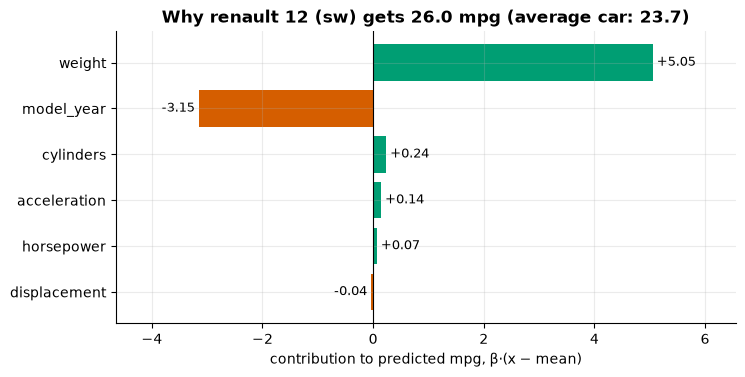

In [6]:
car = X_mte.iloc[[0]]
name = mpg.loc[car.index[0], "name"]
contrib = ols_raw.coef_ * (car.to_numpy()[0] - X_mtr.mean().to_numpy())
base = ols_raw.predict(X_mtr.mean().to_frame().T)[0]
pred = ols_raw.predict(car)[0]
print(f"{name}: base {base:.2f} + contributions {contrib.sum():+.2f} = prediction {pred:.2f} (actual {y_mte.iloc[0]:.1f})")
print("decomposition exact:", np.isclose(base + contrib.sum(), pred))

fig, ax = plt.subplots(figsize=(8, 3.8))
o = np.argsort(np.abs(contrib))
ax.barh(np.array(num_mpg)[o], contrib[o], color=[PALETTE[2] if c > 0 else PALETTE[3] for c in contrib[o]])
for i, c in enumerate(contrib[o]):
    ax.text(c, i, f" {c:+.2f} ", va="center", ha="left" if c >= 0 else "right", fontsize=9)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlim(contrib.min() - 1.5, contrib.max() + 1.5)
ax.set(title=f"Why {name} gets {pred:.1f} mpg (average car: {base:.1f})",
       xlabel="contribution to predicted mpg, β·(x − mean)")
savefig("linear_local_contributions")
plt.show()

## 3 · Trees: intrinsically interpretable (when small)

A shallow tree *is* its own explanation: a handful of if/else rules. We use Titanic survival.

depth-3 tree test accuracy: 0.785
sex encoding: {0: 'female', 1: 'male'}


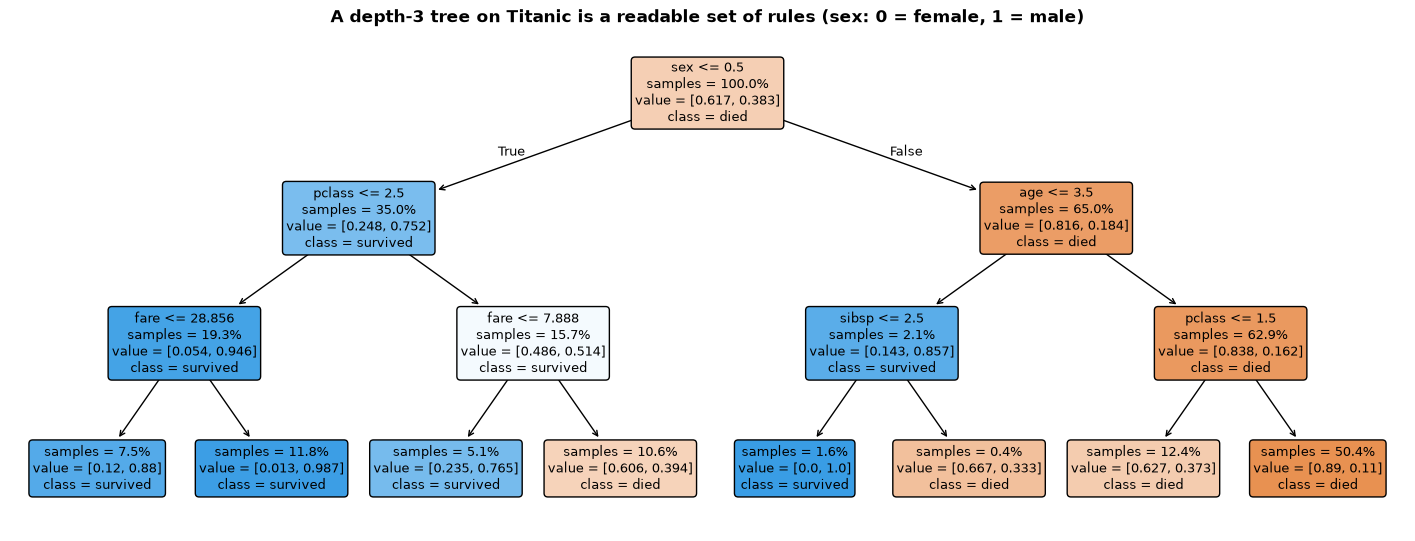

In [7]:
titanic = load_titanic()
feat_t = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
Xt = titanic[feat_t].copy()
yt = titanic["survived"]
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.25, stratify=yt, random_state=RANDOM_STATE)

cat_t, num_t = ["sex", "embarked"], ["pclass", "age", "sibsp", "parch", "fare"]
prep_tree = ColumnTransformer([
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OrdinalEncoder()), cat_t),
    ("num", SimpleImputer(strategy="median"), num_t),
], verbose_feature_names_out=False)
small_tree = Pipeline([("prep", prep_tree), ("tree", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))])
small_tree.fit(Xt_tr, yt_tr)
print(f"depth-3 tree test accuracy: {small_tree.score(Xt_te, yt_te):.3f}")
print("sex encoding:", dict(enumerate(small_tree["prep"].named_transformers_["cat"][-1].categories_[0])))

fig, ax = plt.subplots(figsize=(18, 6.5))
plot_tree(small_tree["tree"], feature_names=small_tree["prep"].get_feature_names_out(), class_names=["died", "survived"],
          filled=True, rounded=True, impurity=False, proportion=True, fontsize=9, ax=ax)
ax.set_title("A depth-3 tree on Titanic is a readable set of rules (sex: 0 = female, 1 = male)")
savefig("tree_titanic")
plt.show()

Beyond depth ~4 the rules become unreadable, and ensembles of hundreds of deep trees are not intrinsically
interpretable at all. For those we need post-hoc tools — starting with the most popular (and most misused) one.

## 4 · Impurity-based feature importance (MDI) and its bias

Random forests expose `feature_importances_`: the **Mean Decrease in Impurity** — for every split on feature $j$,
the weighted Gini decrease, summed over all trees and normalised to 1:

$$\text{MDI}_j = \frac{1}{T}\sum_{t=1}^{T}\sum_{\text{nodes } v \text{ splitting on } j} \frac{n_v}{n}\,\Delta\text{Gini}(v).$$

Two problems:
1. It is computed on the **training** data, so it rewards features the forest used to **overfit**.
2. Features with **many possible split points** (continuous or high-cardinality) get more chances to produce a
   split that looks good by luck.

**Experiment:** add two columns of pure noise to Titanic — a continuous `random_num` and a categorical `random_cat`
with 100 levels — and see what the forest thinks of them.

In [8]:
Xn = Xt.copy()
Xn["random_num"] = rng.normal(size=len(Xn))
Xn["random_cat"] = rng.integers(0, 100, size=len(Xn)).astype(str)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yt, test_size=0.25, stratify=yt, random_state=RANDOM_STATE)

cat_n, num_n = ["sex", "embarked", "random_cat"], ["pclass", "age", "sibsp", "parch", "fare", "random_num"]
prep_rf = ColumnTransformer([
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)), cat_n),
    ("num", SimpleImputer(strategy="median"), num_n),
], verbose_feature_names_out=False)
rf = Pipeline([("prep", prep_rf), ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))])
rf.fit(Xn_tr, yn_tr)
print(f"RF train accuracy: {rf.score(Xn_tr, yn_tr):.3f}   test accuracy: {rf.score(Xn_te, yn_te):.3f}")

mdi = pd.Series(rf["rf"].feature_importances_, index=rf["prep"].get_feature_names_out()).sort_values()
mdi.round(3).to_frame("MDI importance").iloc[::-1]

RF train accuracy: 1.000   test accuracy: 0.785


,MDI importance
sex,0.250
fare,0.178
age,0.141
random_num,0.129
random_cat,0.125
pclass,0.082
sibsp,0.035
embarked,0.030
parch,0.028


The two noise columns get **substantial** MDI importance — more than `pclass`, `sibsp`, `parch` and `embarked`,
which genuinely matter for survival. The train/test accuracy gap shows the forest memorised the training set, and it
did so partly by splitting on noise.

## 5 · Permutation importance

Idea (Breiman, 2001): if feature $j$ matters, **breaking its link to the target** should hurt the score. Break the link
by randomly **shuffling column $j$** of a held-out set, keeping everything else intact:

$$\text{PI}_j = s(\hat f, X, y) - \frac{1}{R}\sum_{r=1}^{R} s\big(\hat f, X^{(\pi_r, j)}, y\big),$$

where $X^{(\pi_r, j)}$ has column $j$ permuted. It needs no retraining, works for any model and any metric, and —
computed on **test** data — it only rewards features that help **generalise**.

### From scratch

We shuffle the *raw* DataFrame column (before the pipeline), so the explanation is in terms of original features.
To be able to compare **exactly** with sklearn we mimic its random-number scheme: one seed is drawn from
`RandomState(42)`, and every feature is shuffled with a fresh `RandomState(seed)`.

In [9]:
def permutation_importance_scratch(model, X, y, n_repeats=10, random_state=RANDOM_STATE):
    baseline = model.score(X, y)
    seed = np.random.RandomState(random_state).randint(np.iinfo(np.int32).max + 1)
    importances = np.zeros((X.shape[1], n_repeats))
    for j, col in enumerate(X.columns):
        r = np.random.RandomState(seed)
        X_perm = X.copy()
        idx = np.arange(len(X))
        for rep in range(n_repeats):
            r.shuffle(idx)
            X_perm[col] = X_perm[col].to_numpy()[idx]      # shuffle column j (again)
            importances[j, rep] = baseline - model.score(X_perm, y)
    return importances


t0 = time.time()
pi_me = permutation_importance_scratch(rf, Xn_te, yn_te, n_repeats=10)
t_me = time.time() - t0
t0 = time.time()
pi_sk = permutation_importance(rf, Xn_te, yn_te, n_repeats=10, random_state=RANDOM_STATE)
t_sk = time.time() - t0
print(f"from scratch {t_me:.1f}s, sklearn {t_sk:.1f}s")
print("identical to sklearn:", np.allclose(pi_me, pi_sk.importances))
pd.DataFrame({"scratch mean": pi_me.mean(axis=1), "sklearn mean": pi_sk.importances_mean,
              "sklearn std": pi_sk.importances_std}, index=Xn_te.columns).sort_values("sklearn mean", ascending=False).round(4)

from scratch 2.2s, sklearn 2.2s
identical to sklearn: True


,scratch mean,sklearn mean,sklearn std
sex,0.1794,0.1794,0.0224
pclass,0.0821,0.0821,0.0187
age,0.0242,0.0242,0.0201
embarked,0.0076,0.0076,0.0072
fare,0.0045,0.0045,0.0124
random_cat,0.0009,0.0009,0.0118
sibsp,-0.0027,-0.0027,0.0061
parch,-0.0040,-0.0040,0.0088
random_num,-0.0054,-0.0054,0.0056


Now compare MDI with permutation importance on the **training** set and on the **test** set.

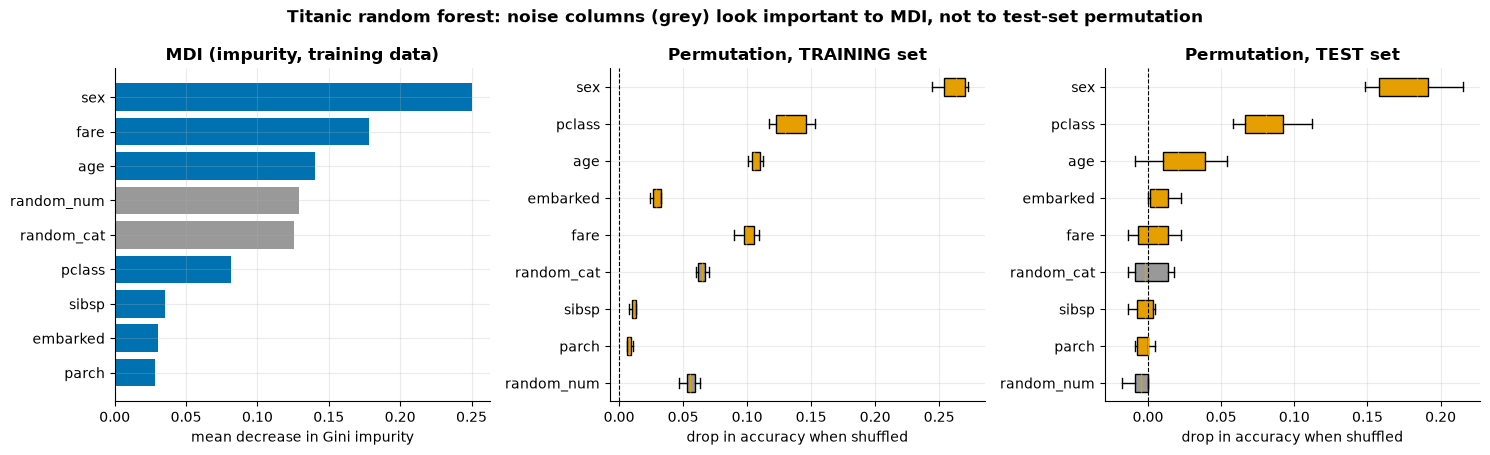

In [10]:
pi_tr = permutation_importance(rf, Xn_tr, yn_tr, n_repeats=10, random_state=RANDOM_STATE)
order_te = np.argsort(pi_sk.importances_mean)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
colors = ["#999999" if c.startswith("random") else PALETTE[0] for c in mdi.index]
axes[0].barh(mdi.index, mdi.values, color=colors)
axes[0].set(title="MDI (impurity, training data)", xlabel="mean decrease in Gini impurity")
for ax, res, title in [(axes[1], pi_tr, "Permutation, TRAINING set"), (axes[2], pi_sk, "Permutation, TEST set")]:
    bp = ax.boxplot(res.importances[order_te].T, orientation="horizontal", patch_artist=True,
                    tick_labels=Xn_te.columns[order_te], showfliers=False)
    for patch, c in zip(bp["boxes"], Xn_te.columns[order_te]):
        patch.set_facecolor("#999999" if c.startswith("random") else PALETTE[1])
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set(title=title, xlabel="drop in accuracy when shuffled")
fig.suptitle("Titanic random forest: noise columns (grey) look important to MDI, not to test-set permutation",
             fontweight="bold")
fig.tight_layout()
savefig("mdi_vs_permutation")
plt.show()

- **MDI** ranks the pure-noise columns among the top features.
- **Permutation on the training set** also credits them a little: the forest memorised them.
- **Permutation on the test set** puts both noise columns at ≈ 0 (boxes straddle zero) — shuffling noise cannot
  hurt generalisation. `sex` dominates, followed by `pclass` and `age`. Note `fare`: second by MDI, but ≈ 0 on test
  data — its information largely overlaps with `pclass`, and its many split points were used to overfit.

> The boxes show the spread over the 10 shuffles; if a box crosses 0 the feature is not distinguishable from noise.

## 6 · Correlated features fool permutation importance

Permutation importance asks "how much worse is the model without the information in $x_j$?" If a **correlated
twin** $x_k$ carries the same information, the model can partly fall back on it, so **both** look less important.
Worse, shuffling one of two strongly correlated features creates unrealistic rows (e.g. a heavy car with a tiny engine),
so the model is evaluated off the data manifold.

**Experiment** on the diabetes data (442 patients, 10 baseline variables, target = disease progression after one
year): fit a random forest, then add a noisy **copy** of `bmi` and refit.

In [11]:
diab = load_diabetes(as_frame=True)
Xd, yd = diab.data, diab.target
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, random_state=RANDOM_STATE)

def rf_perm(Xtr, Xte):
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE).fit(Xtr, yd_tr)
    p = permutation_importance(m, Xte, yd_te, n_repeats=10, random_state=RANDOM_STATE)
    return m, pd.Series(p.importances_mean, index=Xte.columns)

rf_d, imp_d = rf_perm(Xd_tr, Xd_te)
Xd2_tr, Xd2_te = Xd_tr.copy(), Xd_te.copy()
noise_sd = 0.1 * Xd["bmi"].std()
Xd2_tr["bmi_copy"] = Xd_tr["bmi"] + rng.normal(0, noise_sd, len(Xd_tr))
Xd2_te["bmi_copy"] = Xd_te["bmi"] + rng.normal(0, noise_sd, len(Xd_te))
rf_d2, imp_d2 = rf_perm(Xd2_tr, Xd2_te)
print(f"corr(bmi, bmi_copy) = {np.corrcoef(Xd2_tr['bmi'], Xd2_tr['bmi_copy'])[0, 1]:.3f}")
print(f"test R²  original: {rf_d.score(Xd_te, yd_te):.3f}   with copy: {rf_d2.score(Xd2_te, yd_te):.3f}")
cmp = pd.DataFrame({"original": imp_d, "with bmi_copy": imp_d2}).sort_values("with bmi_copy", ascending=False)
cmp.round(3)

corr(bmi, bmi_copy) = 0.995
test R²  original: 0.485   with copy: 0.483


,original,with bmi_copy
s5,0.275,0.275
bmi,0.255,0.074
bmi_copy,NaN,0.047
bp,0.037,0.045
s6,0.019,0.023
sex,0.018,0.014
s3,0.015,0.011
age,0.007,0.007
s4,0.006,0.005
s2,0.003,0.002


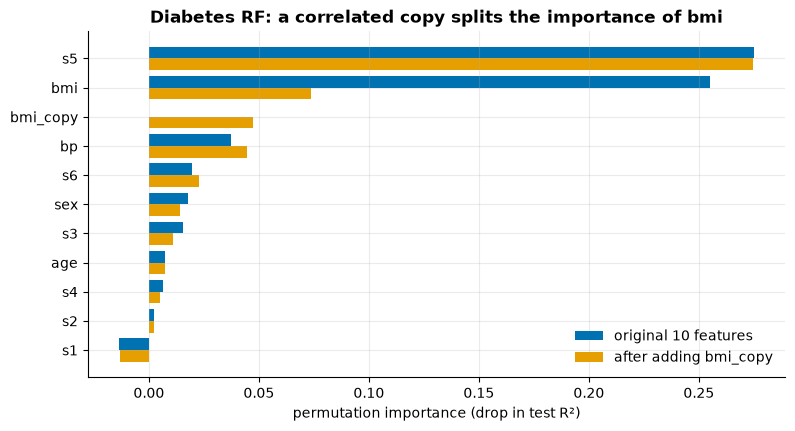

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
cmp_plot = cmp.sort_values("with bmi_copy")
y_pos = np.arange(len(cmp_plot))
ax.barh(y_pos + 0.2, cmp_plot["original"].fillna(0), height=0.4, label="original 10 features", color=PALETTE[0])
ax.barh(y_pos - 0.2, cmp_plot["with bmi_copy"], height=0.4, label="after adding bmi_copy", color=PALETTE[1])
ax.set_yticks(y_pos, cmp_plot.index)
ax.set(title="Diabetes RF: a correlated copy splits the importance of bmi",
       xlabel="permutation importance (drop in test R²)")
ax.legend(loc="lower right")
savefig("correlated_permutation")
plt.show()

Test $R^2$ barely changes — the model is just as good — but the importance of `bmi` is now **shared** with its copy,
and neither alone looks as important as `bmi` did before. The diabetes data already contains such a pair:
the serum measurements `s1` (total cholesterol) and `s2` (LDL) are strongly correlated.

### Remedy: cluster correlated features, keep one per cluster

Use the **Spearman rank correlation** $\rho$ (robust to monotone non-linearity), turn it into a distance
$d_{jk} = 1 - |\rho_{jk}|$, build a hierarchical clustering of the *features* (chapter 10!) and keep one
representative per cluster. Permutation importance on the reduced set then answers a clearer question.

feature clusters at cut 0.5 : [['s3', 's4'], ['sex'], ['s1', 's2'], ['bmi', 'bmi_copy'], ['s5'], ['s6'], ['bp'], ['age']]


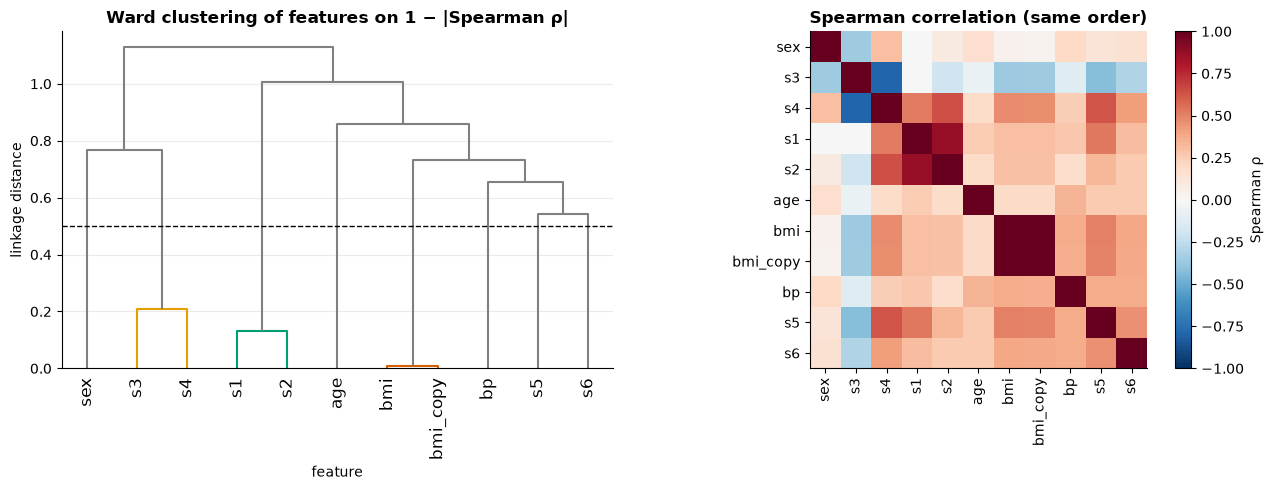

In [13]:
corr = spearmanr(Xd2_tr).correlation
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)
dist = 1 - np.abs(corr)
link = hierarchy.ward(squareform(dist, checks=False))
cut = 0.5
clusters = hierarchy.fcluster(link, t=cut, criterion="distance")
groups = pd.Series(Xd2_tr.columns, index=clusters).groupby(level=0).apply(list)
print("feature clusters at cut", cut, ":", groups.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dendro = hierarchy.dendrogram(link, labels=Xd2_tr.columns.tolist(), ax=axes[0], leaf_rotation=90,
                              color_threshold=cut, above_threshold_color="grey")
axes[0].axhline(cut, color="k", ls="--", lw=1)
axes[0].set(title="Ward clustering of features on 1 − |Spearman ρ|", ylabel="linkage distance", xlabel="feature")
axes[0].grid(axis="x", visible=False)
ordered = dendro["ivl"]
ix = [Xd2_tr.columns.get_loc(c) for c in ordered]
im = axes[1].imshow(corr[np.ix_(ix, ix)], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(ix)), ordered, rotation=90)
axes[1].set_yticks(range(len(ix)), ordered)
axes[1].grid(False)
axes[1].set_title("Spearman correlation (same order)")
fig.colorbar(im, ax=axes[1], label="Spearman ρ")
fig.tight_layout()
savefig("feature_clustering_spearman")
plt.show()

In [14]:
keep = [g[0] for g in groups]
print("keep one per cluster:", keep)
rf_k, imp_k = rf_perm(Xd2_tr[keep], Xd2_te[keep])
print(f"test R² with {len(keep)} features: {rf_k.score(Xd2_te[keep], yd_te):.3f}")
imp_k.sort_values(ascending=False).round(3).to_frame("permutation importance (reduced set)")

keep one per cluster: ['s3', 'sex', 's1', 'bmi', 's5', 's6', 'bp', 'age']


test R² with 8 features: 0.471


,permutation importance (reduced set)
s5,0.273
bmi,0.240
bp,0.043
s3,0.022
sex,0.018
s6,0.015
age,0.005
s1,-0.014


With the redundant copy removed, `bmi` gets its full importance back and the model is unchanged in quality.
(An alternative is **grouped permutation**: shuffle all features in a cluster *together*.)

## 7 · Partial dependence and ICE

Importance says *how much* a feature matters, not *how*. The **partial dependence** of $\hat f$ on feature $x_S$ is
the average prediction when we force $x_S$ to a value and leave everything else as observed:

$$\widehat{\text{PD}}_S(v) = \frac{1}{n}\sum_{i=1}^{n} \hat f\big(x_S = v,\; x_{C}^{(i)}\big).$$

An **ICE curve** (Individual Conditional Expectation) is the same thing **without the average** — one curve per row:
$\hat f(x_S=v, x_C^{(i)})$. The PDP is the mean of the ICE curves; ICE reveals **heterogeneity** (interactions) that the
average hides.

We model `mpg` with gradient boosting, including the categorical `origin`.

In [15]:
Xm_full = mpg[num_mpg + ["origin"]]
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm_full, y_mpg, test_size=0.25, random_state=RANDOM_STATE)
prep_m = ColumnTransformer([
    ("num", "passthrough", num_mpg),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["origin"]),
], verbose_feature_names_out=False)
hgb = Pipeline([("prep", prep_m),
                ("hgb", HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                                      random_state=RANDOM_STATE))])
hgb.fit(Xm_tr, ym_tr)
print(f"HGB test R²: {hgb.score(Xm_te, ym_te):.3f}  (linear model: {ols_std.score(X_mte, y_mte):.3f})")

HGB test R²: 0.871  (linear model: 0.799)


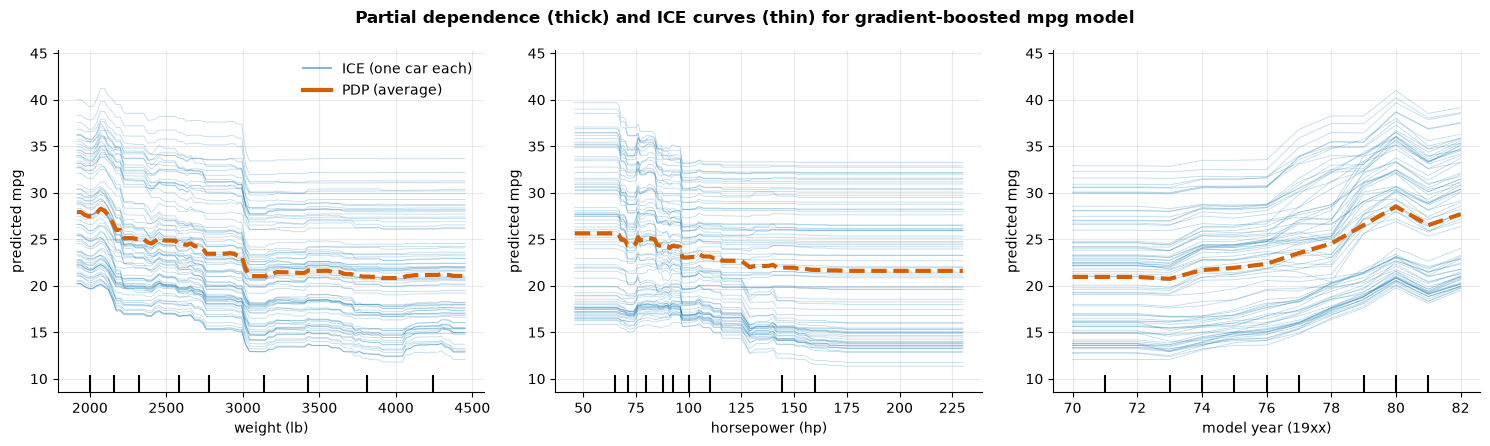

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
disp = PartialDependenceDisplay.from_estimator(
    hgb, Xm_tr, ["weight", "horsepower", "model_year"], kind="both", subsample=80,
    random_state=RANDOM_STATE, ax=axes, ice_lines_kw={"color": PALETTE[0], "alpha": 0.25, "linewidth": 0.6},
    pd_line_kw={"color": PALETTE[3], "linewidth": 3})
units = {"weight": "weight (lb)", "horsepower": "horsepower (hp)", "model_year": "model year (19xx)"}
for ax in disp.axes_.ravel():
    ax.set_xlabel(units[ax.get_xlabel()])
    ax.set_ylabel("predicted mpg")
for ax in disp.axes_.ravel():
    if ax.get_legend():
        ax.get_legend().remove()
disp.axes_.ravel()[0].legend([Line2D([], [], color=PALETTE[0], alpha=0.5), Line2D([], [], color=PALETTE[3], lw=3)],
                        ["ICE (one car each)", "PDP (average)"], loc="upper right")
disp.figure_.suptitle("Partial dependence (thick) and ICE curves (thin) for gradient-boosted mpg model",
                      fontweight="bold")
disp.figure_.tight_layout()
savefig("pdp_ice_mpg")
plt.show()

- **weight**: predicted mpg falls steeply up to ~3,000 lb, then flattens — a non-linearity the linear model misses.
- **horsepower**: a decline that is mostly done by ~130 hp; the ICE curves are nearly parallel.
- **model_year**: newer cars are more efficient, with a jump around 1980 (post oil-crisis fuel-economy standards).

Parallel ICE curves mean the effect is roughly **additive**; ICE curves that fan out or cross indicate
**interactions** with other features. The `model_year` curves fan out a little: cars that are predicted to be
efficient anyway (light ones) gain more from being newer.

### 2-D partial dependence: interactions

Forcing **two** features to a grid of values shows their joint effect. If the contours are parallel to an axis
the effects are additive; bends indicate interaction.

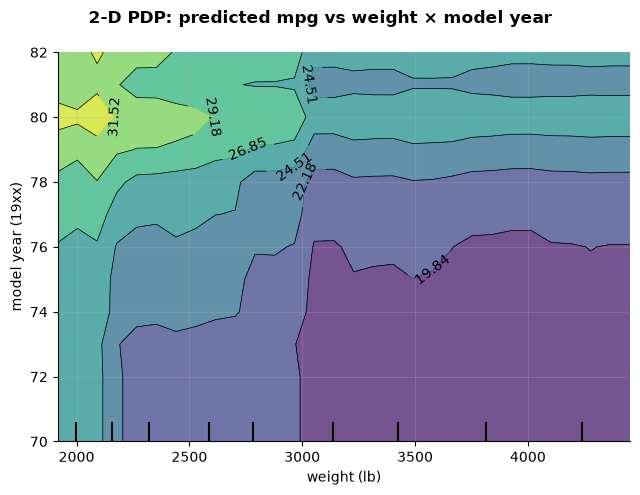

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 5))
disp2 = PartialDependenceDisplay.from_estimator(hgb, Xm_tr, [("weight", "model_year")], kind="average",
                                                grid_resolution=30, ax=ax, contour_kw={"cmap": "viridis"})
disp2.axes_[0, 0].set_xlabel("weight (lb)")
disp2.axes_[0, 0].set_ylabel("model year (19xx)")
disp2.figure_.suptitle("2-D PDP: predicted mpg vs weight × model year", fontweight="bold")
disp2.figure_.tight_layout()
savefig("pdp_2d_weight_year")
plt.show()

### PDP from scratch, verified against `sklearn.inspection.partial_dependence`

The algorithm is literally the formula: for each grid value, overwrite the column for **all** rows, predict, average.
sklearn's default grid is `grid_resolution` evenly spaced values between the 5th and 95th percentiles. We take the grid
from sklearn's output and use `method="brute"` (the model-agnostic algorithm; tree models also have a faster
`"recursion"` shortcut).

grid: [1916.1 1967.9 2019.6] ... [4400.8 4452.6]
average matches sklearn: True
ICE matches sklearn:     True


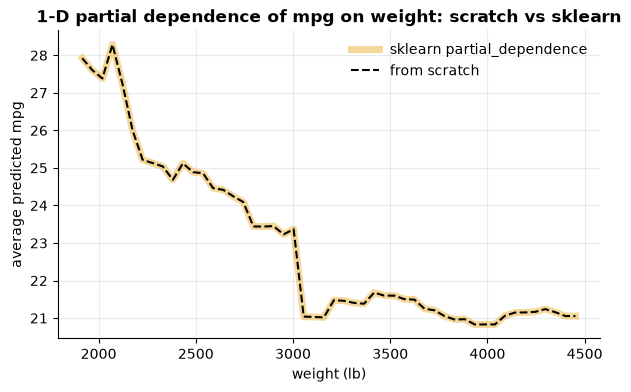

In [18]:
def pdp_scratch(model, X, feature, grid):
    X_mod = X.copy()
    avg = []
    ice = []
    for v in grid:
        X_mod[feature] = v
        p = model.predict(X_mod)
        ice.append(p)
        avg.append(p.mean())
    return np.array(avg), np.array(ice).T          # (n_grid,), (n_rows, n_grid)


res = partial_dependence(hgb, Xm_tr, ["weight"], kind="both", grid_resolution=50, method="brute")
grid = res["grid_values"][0]
pd_me, ice_me = pdp_scratch(hgb, Xm_tr, "weight", grid)
print("grid:", grid[:3].round(1), "...", grid[-2:].round(1))
print("average matches sklearn:", np.allclose(pd_me, res["average"][0]))
print("ICE matches sklearn:    ", np.allclose(ice_me, res["individual"][0]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, res["average"][0], lw=5, alpha=0.4, color=PALETTE[1], label="sklearn partial_dependence")
ax.plot(grid, pd_me, "--", color="k", lw=1.5, label="from scratch")
ax.set(title="1-D partial dependence of mpg on weight: scratch vs sklearn", xlabel="weight (lb)",
       ylabel="average predicted mpg")
ax.legend()
savefig("pdp_scratch_vs_sklearn")
plt.show()

> **Caveat — PDPs assume independence.** Setting `weight = 4500 lb` for a 4-cylinder 1982 compact creates cars that
> never existed. With strongly correlated features the PDP averages over such unrealistic combinations. **ALE plots**
> (accumulated local effects) fix this by only using local changes; ICE curves at least let you see the spread.

## 8 · Further: SHAP and LIME

Not installed in this course environment, but you will meet them everywhere:

- **SHAP** (Lundberg & Lee, 2017) assigns each feature a **Shapley value** from cooperative game theory: its average
  marginal contribution over all orderings of features. Contributions sum exactly to $\hat f(x) - \mathbb E[\hat f]$
  (like our linear decomposition in §2). `TreeSHAP` computes them exactly and fast for tree ensembles.
- **LIME** (Ribeiro et al., 2016) fits a small, weighted linear model to the black box's predictions on perturbed
  samples *around one instance* — a local surrogate.

Both are *local* post-hoc methods; averaging |SHAP| over a dataset gives a global importance that is consistent with
the local explanations. Both inherit the correlated-feature problems discussed above.

In [19]:
print(f"Total notebook runtime: {time.time() - T0:.0f}s")

Total notebook runtime: 80s


## Key takeaways

- Decide what you need: **global** (how does the model behave overall?) vs **local** (why this prediction?), and whether
  an **intrinsically** interpretable model is good enough before reaching for **post-hoc** tools.
- Compare linear coefficients only on **standardised** features, and interpret **groups** of correlated features
  together; bootstrap the coefficients to see how stable they are.
- **MDI** importance is computed on training data and is biased toward continuous / high-cardinality features — pure
  noise can look important. Prefer **permutation importance on held-out data**, and look at its spread.
- Permutation importance **splits credit** between correlated features and evaluates the model on unrealistic rows;
  cluster features (Spearman + dendrogram) and keep one per group, or permute groups.
- **PDPs** show the average effect of a feature; **ICE** curves show individual effects and reveal interactions;
  2-D PDPs show pairwise interactions. All assume you may vary a feature independently of the others.
- Every method explains the **model**, not causality in the world.

## Exercises

1. **Metric matters.** Recompute the Titanic permutation importances with `scoring="roc_auc"` and
   `scoring="neg_log_loss"`. Does the ranking change? *Hint:* pass `scoring=` to `permutation_importance`.
2. **Fix the forest.** Refit the Titanic forest with `min_samples_leaf=10` and recompute MDI. Does the noise columns'
   importance shrink? Why? *Hint:* fewer, larger leaves mean fewer chances to split on noise.
3. **Grouped permutation.** Modify `permutation_importance_scratch` to accept a list of column *groups* and shuffle all
   columns of a group with the same permutation. Apply it to `{bmi, bmi_copy}`. *Hint:* use the same `idx` for every
   column in the group.
4. **Centred ICE.** Plot ICE curves for `model_year` with `centered=True`. What do you learn that the uncentred plot hid?
   *Hint:* `PartialDependenceDisplay.from_estimator(..., kind="both", centered=True)`.
5. **ALE by hand.** Implement a first-order ALE plot for `weight`: bin by quantiles, compute the average prediction
   difference between bin edges for rows inside each bin, then accumulate. Compare with the PDP.
   *Hint:* only rows whose weight lies in the bin are moved, so no unrealistic cars are created.